# Statistical Analysis - Laptop Reviews ABSA Project

This notebook applies hypothesis testing to validate patterns observed during 
exploratory data analysis (Week 05). The goal is to move from "this looks like 
a pattern" to "this pattern is statistically supported" using appropriate tests.

Three statistical questions are examined:
1. Does average rating differ across brands?
2. Is popularity tier associated with rating?
3. Is there a real relationship between review length and rating?

Each question follows the same structure: business question, hypotheses, 
test selection and reasoning, results, and business interpretation.

## Setup

Loading the enriched dataset (includes brand, review_length, and popularity_tier 
columns created during Week 05 EDA) and importing statistical testing libraries.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import kruskal, chi2_contingency, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/processed_data_enriched.csv")
df.info()
df[['brand', 'popularity_tier', 'rating', 'review_length']].describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 16991 entries, 0 to 16990
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_name     16991 non-null  str    
 1   overall_rating   16991 non-null  float64
 2   no_ratings       16991 non-null  int64  
 3   no_reviews       16991 non-null  int64  
 4   rating           16991 non-null  int64  
 5   title            16991 non-null  str    
 6   review           16991 non-null  str    
 7   brand            16991 non-null  str    
 8   review_length    16991 non-null  int64  
 9   popularity_tier  16991 non-null  str    
dtypes: float64(1), int64(4), str(5)
memory usage: 1.3 MB


,brand,popularity_tier,rating,review_length
count,16991,16991,16991.000000,16991.000000
unique,20,3,NaN,NaN
top,HP,High,NaN,NaN
freq,4387,12313,NaN,NaN
mean,NaN,NaN,4.214937,97.503384
std,NaN,NaN,1.185478,124.067123
min,NaN,NaN,1.000000,2.000000
25%,NaN,NaN,4.000000,17.000000
50%,NaN,NaN,5.000000,46.000000
75%,NaN,NaN,5.000000,122.000000


## Question 1: Does average rating differ across brands?

**Business question:** Do certain laptop brands receive systematically higher 
or lower ratings than others?

**H0 (null hypothesis):** Average rating is the same across all brands.

**H1 (alternative hypothesis):** Average rating differs across at least one brand.

**Test choice:** Ratings are heavily skewed toward 5 stars (58% from Week 05 EDA), 
so the normality assumption behind a standard one-way ANOVA is questionable. 
Kruskal-Wallis is used instead, since it compares distributions across groups 
without assuming normality.

In [3]:
# Group ratings by brand
brand_groups = [group["rating"].values for name, group in df.groupby("brand")]

h_stat, p_value = kruskal(*brand_groups)

print("H-statistic:", h_stat)
print("p-value:", p_value)

H-statistic: 309.1797656467742
p-value: 2.6198923857345985e-54


Visualizing the distribution of ratings by brand to understand where the 
differences come from, since Kruskal-Wallis tells us a difference exists but 
not which brands drive it.

A boxplot shows the spread of ratings within each brand, not just the average.
The box itself covers the middle 50% of ratings, the line inside the box is
the median, and the circles are outliers, individual reviews far from the
typical pattern for that brand. This lets us see whether a brand's ratings
are tightly clustered near 5 stars, or spread out with a lot of low scores
pulling the average down.

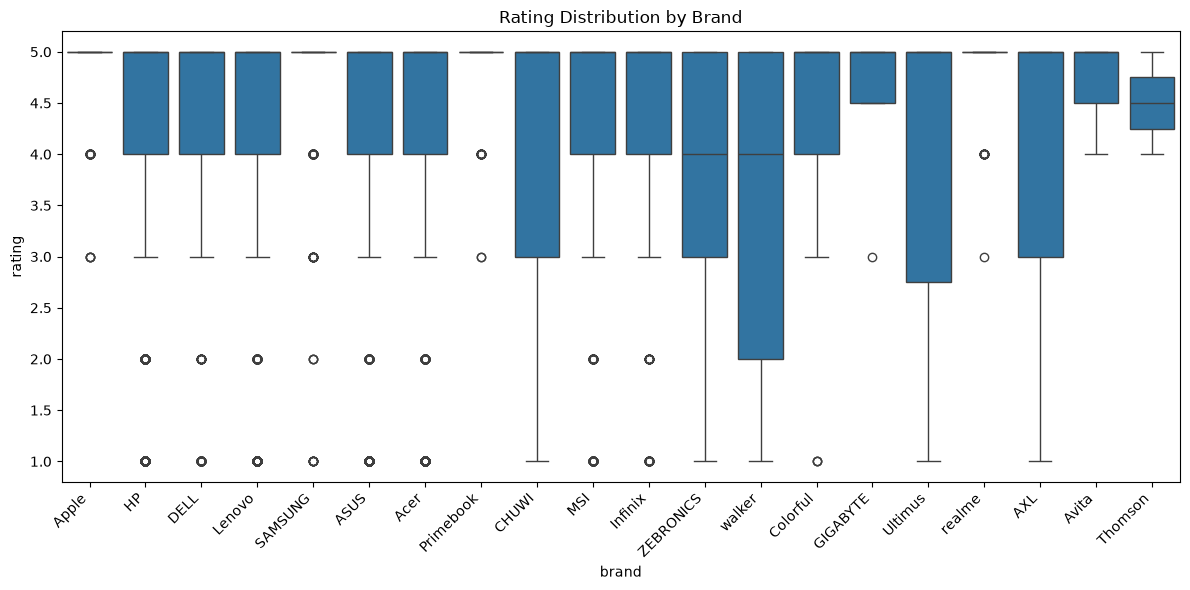

In [6]:
# Boxplot showing the spread of ratings for each brand, ordered by however
# pandas returns groupby brand (alphabetical by default). Rotating x-axis 
# labels so brand names don't overlap.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="brand", y="rating")
plt.xticks(rotation=45, ha='right')
plt.title("Rating Distribution by Brand")
plt.tight_layout()
plt.show()

In [7]:
# For each brand, calculate the average rating, the middle (median) rating,
# and how many reviews that brand actually has. Sorting by mean rating from
# highest to lowest to see which brands perform best.
df.groupby("brand")["rating"].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

,mean,median,count
brand,,,
Primebook,4.865000,5.0,200
Apple,4.823276,5.0,232
realme,4.790000,5.0,100
Avita,4.666667,5.0,3
SAMSUNG,4.632836,5.0,335
Thomson,4.500000,4.5,2
GIGABYTE,4.500000,5.0,4
Colorful,4.444444,5.0,54
Infinix,4.319079,5.0,608


## Checking for small-sample brands

Some brands have very few reviews (for example, Avita has 3, Thomson has 2,
GIGABYTE has 4). Averages calculated from such small samples are unstable,
a single review can shift them dramatically, and they should not be treated
as reliable evidence of brand quality. Before drawing conclusions, brands
with very low review counts are separated out so the main comparison focuses
on brands with enough data to trust.

In [8]:
# Set a minimum review count threshold. Brands below this are excluded from
# the main comparison since their averages aren't statistically meaningful.
MIN_REVIEWS = 30

review_counts = df.groupby("brand")["rating"].count()
low_sample_brands = review_counts[review_counts < MIN_REVIEWS].index.tolist()

print("Brands excluded due to low sample size:", low_sample_brands)

# Re-run Kruskal-Wallis only on brands with sufficient data
df_filtered = df[~df["brand"].isin(low_sample_brands)]
brand_groups_filtered = [group["rating"].values for name, group in df_filtered.groupby("brand")]

h_stat_filtered, p_value_filtered = kruskal(*brand_groups_filtered)

print("H-statistic (filtered):", h_stat_filtered)
print("p-value (filtered):", p_value_filtered)

Brands excluded due to low sample size: ['Avita', 'GIGABYTE', 'Thomson']
H-statistic (filtered): 308.6028663774565
p-value (filtered): 4.206520882827599e-56


### Interpretation

There is strong statistical evidence that average rating differs across 
laptop brands (Kruskal-Wallis H = 308.60, p < 0.001), even after excluding 
brands with fewer than 30 reviews to remove noise from small, unreliable 
samples.

Looking at the brand-level averages, established brands with high review 
volume such as Apple, Samsung, and Primebook cluster near the top (mean 
ratings above 4.6), while brands such as ZEBRONICS, Ultimus, and walker sit 
noticeably lower (mean ratings between 3.6 and 3.9), despite having 
reasonable sample sizes (99 to 116 reviews).

This suggests customer satisfaction genuinely varies by brand, rather than 
ratings being uniform noise across the dataset. However, this analysis does 
not explain *why* ratings differ, that requires looking at what customers 
are actually saying, which is the purpose of the aspect-based sentiment 
analysis in later phases of this project.

## Question 2: Is popularity tier associated with rating?

**Business question:** Do more popular products (measured by number of ratings) 
tend to receive different ratings than less popular products?

**H0 (null hypothesis):** Rating is independent of popularity tier, knowing a 
product's popularity tells us nothing about its rating.

**H1 (alternative hypothesis):** Rating is associated with popularity tier.

**Test choice:** Both `popularity_tier` (Low/Medium/High) and `rating` (1-5) 
are categorical variables here, so a Chi-square test of independence is used 
to check whether the two are related, rather than independent of each other.

In [9]:
# Build a contingency table: rows are popularity tiers, columns are rating
# values, and each cell counts how many reviews fall into that combination.
contingency_table = pd.crosstab(df["popularity_tier"], df["rating"])
contingency_table

rating,1,2,3,4,5
popularity_tier,,,,,
High,773,314,1007,3034,7185
Low,80,18,50,162,450
Medium,442,121,319,852,2184


In [10]:
# Chi-square test of independence: compares the observed counts in the table
# above against what we'd expect to see if popularity_tier and rating were
# completely unrelated. A large chi2 value and small p-value means the
# observed pattern is unlikely to be due to chance.
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 128.53468968485276
p-value: 5.692358216063209e-24
Degrees of freedom: 8


### Interpretation

There is strong statistical evidence that rating is associated with 
popularity tier (Chi-square = 128.53, df = 8, p < 0.001). Rating and 
popularity are not independent of each other.

Looking at the proportions within each tier, High-popularity products show 
a heavier concentration of 5-star ratings relative to their total volume 
compared to Low and Medium tiers, which show relatively more 1, 2, and 3-star 
ratings as a share of their total reviews.

This lines up with the pattern seen in EDA, where low-popularity 
products showed more volatile ratings while high-popularity products 
stabilized around 4.2 to 4.4. A likely explanation is that products which 
build up a large number of ratings tend to be ones that have already proven 
themselves to customers, meaning sustained popularity and higher satisfaction 
reinforce each other. Products with few ratings may include newer listings, 
niche products, or ones that failed to gain traction, all of which naturally 
show more inconsistent feedback.

This is an association, not a causal claim, popularity does not necessarily 
cause higher ratings, and higher ratings do not necessarily cause popularity. 
Both may be driven by underlying product quality.

## Question 3: Is there a real relationship between review length and rating?

**Business question:** Do customers who write longer reviews tend to give 
higher or lower ratings?

**H0 (null hypothesis):** There is no correlation between review length and rating.

**H1 (alternative hypothesis):** There is a correlation between review length 
and rating.

**Test choice:** Spearman correlation is used rather than Pearson, since 
`rating` is an ordinal, heavily skewed variable (not continuous and normally 
distributed), and Spearman measures monotonic relationships without assuming 
normality, which fits this data better.

In [11]:
# Spearman correlation measures whether review_length and rating tend to
# rise and fall together (a monotonic relationship), without assuming either
# variable is normally distributed. Returns a correlation coefficient
# (-1 to 1) and a p-value testing whether that correlation is significant.
corr, p_value = spearmanr(df["review_length"], df["rating"])

print("Spearman correlation coefficient:", corr)
print("p-value:", p_value)

Spearman correlation coefficient: -0.11169215454126565
p-value: 2.6615838062532428e-48


### Interpretation

There is a statistically significant negative correlation between review 
length and rating (Spearman's rho = -0.112, p < 0.001). Because p < 0.05, 
we reject H0, there is technically evidence of a relationship.

However, the correlation coefficient itself is very weak. A value of -0.112 
is close to 0, meaning review length explains almost none of the variation 
in rating. In practical terms, knowing how long a review is tells you almost 
nothing useful about whether it's a high or low rating.

This is a clear example of statistical significance versus business 
significance. With 16,991 reviews, even a very small, practically 
meaningless relationship can produce a very small p-value, because p-values 
are sensitive to sample size, not just effect size. The correct business 
takeaway is not "longer reviews mean lower ratings," but rather "review 
length is not a meaningful predictor of rating on its own."

This is consistent with the EDA finding of near-zero correlation 
between review_length and star rating, now confirmed with a formal 
significance test rather than just a visual impression.

## Conclusion

This notebook applied three hypothesis tests to validate patterns observed 
during EDA section:

1. **Brand and rating**: Average rating differs significantly across brands 
   (Kruskal-Wallis, p < 0.001), even after excluding brands with fewer than 
   30 reviews. Established, high-volume brands like Apple, Samsung, and 
   Primebook show consistently higher ratings than lower-volume brands like 
   ZEBRONICS and walker.

2. **Popularity and rating**: Rating is significantly associated with 
   popularity tier (Chi-square, p < 0.001). High-popularity products show a 
   heavier concentration of 5-star ratings, consistent with the EDA finding 
   that low-popularity products have more volatile ratings.

3. **Review length and rating**: While statistically significant (Spearman, 
   p < 0.001), the correlation between review length and rating is very weak 
   (rho = -0.112), meaning review length is not a practically meaningful 
   predictor of rating. This is a useful example of statistical significance 
   not implying business significance.

Together, these results confirm that brand and product popularity are 
meaningfully linked to customer satisfaction, while review length is not. 
These findings support moving into the next phase of the project, Aspect 
Extraction, where the focus shifts from *whether* ratings differ to 
*understanding why*, by identifying which specific product aspects (battery, 
display, build quality, etc.) drive positive or negative sentiment.